# Machine Learning for Natural Language Processing

## `Overview`

This notebook demonstrates a complete NLP pipeline for Bengali sentiment analysis on e-commerce data.

## `Workflow`

1. **Data Collection** - Load e-commerce dataset
2. **Data Cleaning** - Handle missing values, remove duplicates, standardize text
3. **Text Preprocessing** - Tokenization, stopword removal, normalization
4. **Vectorization** - Convert text to numerical features (Bag of Words, TF-IDF, n-grams)
5. **Train-Test Split** - Stratified split to maintain class distribution
6. **Model Training** - Train Logistic Regression with TF-IDF features
7. **Model Evaluation** - Assess performance using multiple metrics
8. **Cross-Validation** - Validate model stability across different data splits
9. **Inference** - Make predictions on new comments

## `Key Concepts`

### `Text Vectorization Methods`

- **Bag of Words (CountVectorizer)** - Simple word count features
- **TF-IDF (TfidfVectorizer)** - Term frequency-inverse document frequency; gives importance to rare but meaningful words
- **N-grams** - Capture word sequences for better context

### `Evaluation Metrics`

- **Accuracy** - Overall correctness of predictions
- **Precision** - Proportion of positive predictions that are correct
- **Recall** - Proportion of actual positives correctly identified
- **F1-Score** - Harmonic mean of precision and recall
- **Confusion Matrix** - Detailed breakdown of predictions vs actual labels

### `Model Architecture`

- **Pipeline** - Combines TF-IDF vectorization and Logistic Regression
- **Stratified K-Fold Cross-Validation** - Ensures balanced class distribution across folds
- **Class Weights** - Handles imbalanced dataset by penalizing misclassification of minority classes


In [1]:
from sklearn.feature_extraction.text import CountVectorizer

texts = ["I love this movie", "I love this cat"]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(texts)

print("Vocabulary:")
print(vectorizer.vocabulary_)

print(vectorizer.get_feature_names_out())

print("\nVectorized Texts:")
print(X.toarray())

Vocabulary:
{'love': 1, 'this': 3, 'movie': 2, 'cat': 0}
['cat' 'love' 'movie' 'this']

Vectorized Texts:
[[0 1 1 1]
 [1 1 0 1]]


## CountVectorizer example

`CountVectorizer` converts text into word-count features.

Example: if a word appears in a sentence, its count becomes a number.

This is like making a checklist of words for every comment.


In [2]:
texts = ["মুভিটি খুব ভালো", "মুভিটি খুব বাজে"]

count_vectorizer = CountVectorizer(
    tokenizer=lambda text: text.split(),  # simple whitespace tokenizer for Bengali text
    token_pattern=None,  # required when custom tokenizer is used
)

X_count = count_vectorizer.fit_transform(texts)

print("Vocabulary:")
print(count_vectorizer.vocabulary_)

print("\nFeature names:")
print(count_vectorizer.get_feature_names_out())

print("\nCount vectors:")
print(X_count.toarray())

Vocabulary:
{'মুভিটি': 3, 'খুব': 0, 'ভালো': 2, 'বাজে': 1}

Feature names:
['খুব' 'বাজে' 'ভালো' 'মুভিটি']

Count vectors:
[[1 0 1 1]
 [1 1 0 1]]


## TF-IDF Vectorizer example

`TF-IDF` also converts text into numbers, but it gives more importance to words that are useful and less importance to words that appear everywhere.

In sentiment analysis, TF-IDF is often better than simple word counts because common words become less dominant.


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = ["মুভিটি খুব ভালো", "মুভিটি খুব বাজে "]

vectorizer = CountVectorizer(tokenizer=lambda x: x.split(), token_pattern=None)

X = vectorizer.fit_transform(texts)

print(vectorizer.get_feature_names_out())

print("\nVectorized Texts:")
print(X.toarray())

['খুব' 'বাজে' 'ভালো' 'মুভিটি']

Vectorized Texts:
[[1 0 1 1]
 [1 1 0 1]]


Machine Learning


## 1. Import libraries


In [4]:
# Core data libraries
from pathlib import Path
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn tools
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# Model saving
import joblib

In [5]:
# Dataset import
df = pd.read_excel(r"../DataSets/E-commerce.xlsx")

C:\Users\infor\AppData\Roaming\Python\Python313\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [6]:
print(df.shape)
print(df.head(3))

(949, 3)
               Name                                            Comment  Tag
0     Monirul Ahmed  আদৌও কি আমার রিফান্ড পাবো, প্রিয় ই- ভালি?????...  Bad
1       Tanzil Ayon  আপনাদের প্রায়োরিটি স্টোর/ T10 এর আগের পণ্য গু...  Bad
2  HM Athir Al Azad  Order করেছি কিন্তু এখনো নোটিফিকেশন এর মাধ্যমে ...  Bad


In [7]:
df.isnull().sum()

Name       0
Comment    0
Tag        1
dtype: int64

In [8]:
df["Tag"].value_counts()

Tag
Bad        401
Good       364
Neutral    183
Name: count, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(353)

In [10]:
new_df = df.dropna(subset=["Comment", "Tag"])
new_df.duplicated(subset=["Comment", "Tag"]).sum()

np.int64(379)

In [11]:
def clean_text(text):
    text = str(text).strip()
    text = " ".join(text.split())  # remove extra whitespace
    return text


data = df[["Comment", "Tag"]].copy()

data = data.dropna(subset=["Comment", "Tag"]).copy()

# Clean text and label values
data["Comment"] = data["Comment"].apply(clean_text)
data["Tag"] = data["Tag"].astype(str).str.strip()

# Remove empty comments after cleaning
data = data[data["Comment"] != ""].copy()

# Keep only expected classes
valid_labels = ["Bad", "Good", "Neutral"]
data = data[data["Tag"].isin(valid_labels)].copy()

print("Shape after missing-value and label cleaning:", data.shape)
print(data["Tag"].value_counts())

Shape after missing-value and label cleaning: (948, 2)
Tag
Bad        401
Good       364
Neutral    183
Name: count, dtype: int64


In [12]:
Duplicates = True

if Duplicates:
    before = len(data)
    data = data.drop_duplicates(subset=["Comment", "Tag"]).copy()
    removed = before - len(data)
    print(f"Removed {removed} duplicate Comment + Tag rows.")
else:
    print("Duplicates kept.")

print("Final dataset shape:", data.shape)
print("\nFinal label distribution:")
print(data["Tag"].value_counts())

Removed 380 duplicate Comment + Tag rows.
Final dataset shape: (568, 2)

Final label distribution:
Tag
Bad        309
Neutral    157
Good       102
Name: count, dtype: int64


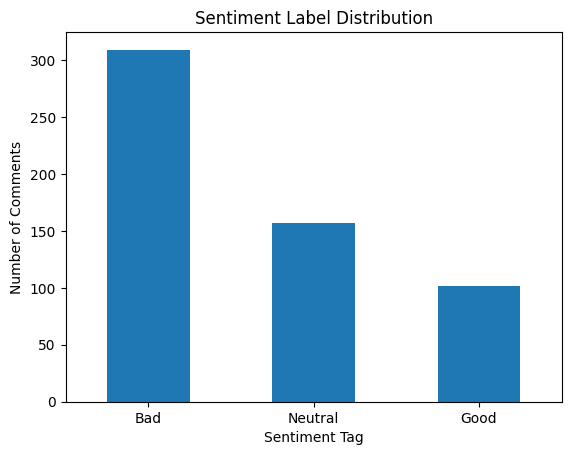

In [13]:
# Visualize label distribution
# This helps us see whether the dataset is balanced or imbalanced.
data["Tag"].value_counts().plot(kind="bar")
plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment Tag")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.show()

## Create input `X` and target `y`

In supervised learning:

- `X` = input data/features, here the `Comment`
- `y` = target/output label, here the `Tag`


In [14]:
X = data["Comment"]
y = data["Tag"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nSample input comment:")
print(X.iloc[0])
print("\nSample target label:")
print(y.iloc[0])

X shape: (568,)
y shape: (568,)

Sample input comment:
আদৌও কি আমার রিফান্ড পাবো, প্রিয় ই- ভালি????? আর কত কাল???

Sample target label:
Bad


## Train-test split

We split the data so the model is tested on comments it did not see during training.

`stratify=y` keeps the class distribution similar in train and test sets.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training samples: 454
Testing samples: 114

Train label distribution:
Tag
Bad        0.544
Neutral    0.275
Good       0.181
Name: proportion, dtype: float64

Test label distribution:
Tag
Bad        0.544
Neutral    0.281
Good       0.175
Name: proportion, dtype: float64


## Build the NLP model pipeline

The pipeline has two steps:

1. `TfidfVectorizer`: converts Bengali text into numeric features
2. `LogisticRegression`: learns the relationship between text features and sentiment labels

This prevents data leakage because TF-IDF is fitted only on training data during model training.


In [16]:
def bangla_tokenizer(text):
    """Simple Bengali tokenizer -> whitespace tokenization"""
    return text.split()


model_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                tokenizer=bangla_tokenizer,
                token_pattern=None,
                ngram_range=(1, 2),  # use single words and two-word combinations
                min_df=2,  # ignore words that appear only once
            ),
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
                class_weight="balanced",  # helps when classes are not perfectly balanced
            ),
        ),
    ]
)

model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",<function ban...001A20EA34AE0>


## Train the model


In [17]:
# Fit the full pipeline on training data
model_pipeline.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## Evaluate the model on test data

We evaluate on the test set because the model has not seen these comments during training.


In [18]:
# Predict labels for unseen test comments
y_pred = model_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.7193
Precision: 0.7250
Recall   : 0.7193
F1-score : 0.7210

Classification Report:
              precision    recall  f1-score   support

         Bad       0.77      0.74      0.75        62
        Good       0.78      0.70      0.74        20
     Neutral       0.61      0.69      0.65        32

    accuracy                           0.72       114
   macro avg       0.72      0.71      0.71       114
weighted avg       0.72      0.72      0.72       114



## Confusion matrix

A confusion matrix shows where the model is making correct and incorrect predictions.

Rows = actual labels.  
Columns = predicted labels.


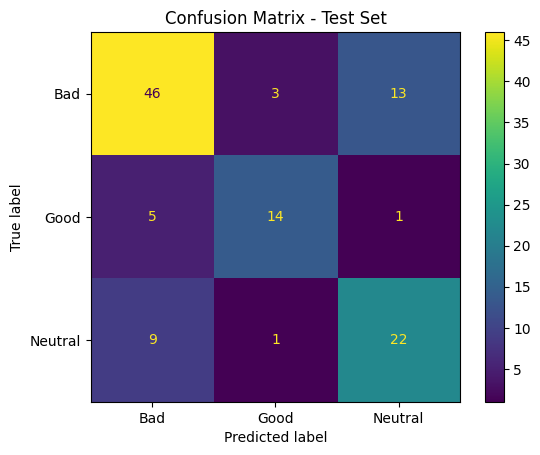

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Test Set")
plt.show()

## Cross-validation

Cross-validation gives a more stable estimate because it trains and tests the model multiple times on different splits.

Here we use weighted F1-score because the dataset has three classes and they are not equally distributed.


In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1_scores = cross_val_score(model_pipeline, X, y, cv=cv, scoring="f1_weighted")

print("Cross-validation weighted F1 scores:", np.round(cv_f1_scores, 4))
print(f"Mean weighted F1: {cv_f1_scores.mean():.4f}")
print(f"Standard deviation: {cv_f1_scores.std():.4f}")

Cross-validation weighted F1 scores: [0.7315 0.6973 0.7614 0.6723 0.7506]
Mean weighted F1: 0.7226
Standard deviation: 0.0333


## Try sample predictions


In [21]:
sample_comments = [
    "আদৌও কি আমার রিফান্ড পাবো, প্রিয় ই- ভালি",
    "আলহামদুলিল্লাহ রিফান্ড পেয়েছি",
    "আপডেট দিবেন আশা করি",
]

sample_predictions = model_pipeline.predict(sample_comments)

for comment, prediction in zip(sample_comments, sample_predictions):
    print(f"Comment: {comment}")
    print(f"Predicted Tag: {prediction}")
    print("-" * 50)

Comment: আদৌও কি আমার রিফান্ড পাবো, প্রিয় ই- ভালি
Predicted Tag: Bad
--------------------------------------------------
Comment: আলহামদুলিল্লাহ রিফান্ড পেয়েছি
Predicted Tag: Good
--------------------------------------------------
Comment: আপডেট দিবেন আশা করি
Predicted Tag: Neutral
--------------------------------------------------


## Save the trained model

Saving the pipeline is important because it saves both:

1. the TF-IDF vectorizer
2. the trained Logistic Regression model

Later, you can load this file and predict new comments without retraining.


In [22]:
MODEL_PATH = "bangla_ecommerce_sentiment_model.pkl"

joblib.dump(model_pipeline, MODEL_PATH)
print(f"Model saved as: {MODEL_PATH}")

Model saved as: bangla_ecommerce_sentiment_model.pkl


## Load saved model and predict manually


In [23]:
loaded_model = joblib.load(MODEL_PATH)

new_comment = ["মে মাসের বাইক রিফান্ডের নোটিশ কবে দিবেন"]
prediction = loaded_model.predict(new_comment)

print("New comment:", new_comment[0])
print("Predicted sentiment:", prediction[0])

New comment: মে মাসের বাইক রিফান্ডের নোটিশ কবে দিবেন
Predicted sentiment: Neutral
